# Fine-Tuning EfficientNetB5 for Gender Classification on the Adience Dataset

In [2]:
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib import pyplot as plt
from sklearn.decomposition import PCA
import pylab as pl
import scipy.optimize as opt
from sklearn import preprocessing
from sklearn.model_selection import KFold

import cv2
import random
from PIL import Image
import os

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.layers import Flatten, Dense, GlobalMaxPooling2D, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.applications.efficientnet import EfficientNetB5
from tensorflow.keras import optimizers
from tensorflow import keras

import os
from tensorflow.keras import layers
from tensorflow.keras import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint, EarlyStopping
from tensorflow.keras.models import Sequential,load_model,save_model
from tensorflow.keras.layers import Dense,Conv2D,Flatten,MaxPooling2D
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.optimizers import Adam

import tensorflow as tf
print(tf.__version__)

2.13.0


# Preprocess Adience Dataset

In [6]:
# load data
ADIENCE_PATH = r"C:\Users\cheec\Downloads\AdienceGender"
print(os.listdir(path=ADIENCE_PATH))

all_folds={}
for i in range(5):
    all_folds[i]=pd.read_csv(os.path.join(ADIENCE_PATH, f'fold_{i}_data.txt'),sep = "\t" )

['aligned', 'fold_0_data.txt', 'fold_1_data.txt', 'fold_2_data.txt', 'fold_3_data.txt', 'fold_4_data.txt']


In [7]:
total_data = pd.concat([all_folds[i] for i in range(5)],ignore_index=True)
total_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19370 entries, 0 to 19369
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   user_id             19370 non-null  object
 1   original_image      19370 non-null  object
 2   face_id             19370 non-null  int64 
 3   age                 19370 non-null  object
 4   gender              18591 non-null  object
 5   x                   19370 non-null  int64 
 6   y                   19370 non-null  int64 
 7   dx                  19370 non-null  int64 
 8   dy                  19370 non-null  int64 
 9   tilt_ang            19370 non-null  int64 
 10  fiducial_yaw_angle  19370 non-null  int64 
 11  fiducial_score      19370 non-null  int64 
dtypes: int64(8), object(4)
memory usage: 1.8+ MB


In [8]:
total_data.head()

,user_id,original_image,face_id,age,gender,x,y,dx,dy,tilt_ang,fiducial_yaw_angle,fiducial_score
0,30601258@N03,10399646885_67c7d20df9_o.jpg,1,"(25, 32)",f,0,414,1086,1383,-115,30,17
1,30601258@N03,10424815813_e94629b1ec_o.jpg,2,"(25, 32)",m,301,105,640,641,0,0,94
2,30601258@N03,10437979845_5985be4b26_o.jpg,1,"(25, 32)",f,2395,876,771,771,175,-30,74
3,30601258@N03,10437979845_5985be4b26_o.jpg,3,"(25, 32)",m,752,1255,484,485,180,0,47
4,30601258@N03,11816644924_075c3d8d59_o.jpg,2,"(25, 32)",m,175,80,769,768,-75,0,34


f    9372
m    8120
u    1099
Name: gender, dtype: int64


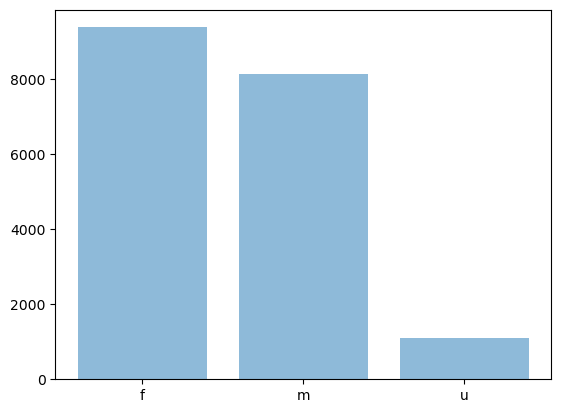

In [9]:
# bar chart
gender = ['f','m','u']
plt.bar(gender, total_data.gender.value_counts(), align='center', alpha=0.5)
print(total_data.gender.value_counts())
plt.show()

In [10]:
df = total_data[['age', 'gender', 'x', 'y', 'dx', 'dy']].copy()

img_path = []

for row in total_data.iterrows():
    path = f"{ADIENCE_PATH}/aligned/"+row[1].user_id+"/landmark_aligned_face."+str(row[1].face_id)+"."+row[1].original_image
    img_path.append(path)
df['img_path'] = img_path

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19370 entries, 0 to 19369
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   age       19370 non-null  object
 1   gender    18591 non-null  object
 2   x         19370 non-null  int64 
 3   y         19370 non-null  int64 
 4   dx        19370 non-null  int64 
 5   dy        19370 non-null  int64 
 6   img_path  19370 non-null  object
dtypes: int64(4), object(3)
memory usage: 1.0+ MB


In [11]:
df = df.dropna()
unbiased_data = df[df.gender != 'u'].copy()
unbiased_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 17492 entries, 0 to 19345
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   age       17492 non-null  object
 1   gender    17492 non-null  object
 2   x         17492 non-null  int64 
 3   y         17492 non-null  int64 
 4   dx        17492 non-null  int64 
 5   dy        17492 non-null  int64 
 6   img_path  17492 non-null  object
dtypes: int64(4), object(3)
memory usage: 1.1+ MB


In [12]:
gender_to_label_map = {
    'f' : 0,
    'm' : 1
}


# label_to_age_map = {value: key for key, value in age_to_label_map.items()}

unbiased_data['gender'] = unbiased_data['gender'].apply(lambda g: gender_to_label_map[g])

unbiased_data.head()

,age,gender,x,y,dx,dy,img_path
0,"(25, 32)",0,0,414,1086,1383,C:\Users\cheec\Downloads\AdienceGender/aligned...
1,"(25, 32)",1,301,105,640,641,C:\Users\cheec\Downloads\AdienceGender/aligned...
2,"(25, 32)",0,2395,876,771,771,C:\Users\cheec\Downloads\AdienceGender/aligned...
3,"(25, 32)",1,752,1255,484,485,C:\Users\cheec\Downloads\AdienceGender/aligned...
4,"(25, 32)",1,175,80,769,768,C:\Users\cheec\Downloads\AdienceGender/aligned...


# Create Dataset

In [36]:
X = unbiased_data[['img_path']]
y = unbiased_data[['gender']]
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print('Train data shape {}'.format(X_train.shape))
print('Test data shape {}'.format(X_test.shape))

Train data shape (12216, 1)
Test data shape (5236, 1)


In [37]:
train_images = []
test_images = []

for row in X_train.iterrows():
    image = Image.open(row[1].img_path)
    image = image.resize((227, 227))   # Resize the image
    data = np.asarray(image)
    train_images.append(data)

for row in X_test.iterrows():
    image = Image.open(row[1].img_path)
    image = image.resize((227, 227))  # Resize the image
    data = np.asarray(image)
    test_images.append(data)

train_images = np.asarray(train_images)
test_images = np.asarray(test_images)

print('Train images shape {}'.format(train_images.shape))
print('Test images shape {}'.format(test_images.shape))

Train images shape (12216, 227, 227, 3)
Test images shape (5236, 227, 227, 3)


# Create Model

In [38]:
batch_size = 32
epochs = 20
target_size = (227, 227) # (64, 64)
input_shape = (227, 227, 3) #(64, 64, 3)

# random seed
SEED = 1337
np.random.seed(SEED)
tf.random.set_seed(SEED)

adam = 0.001
fre = -20
FC = 2048
E = 1
patience = 5
verbose = 1
factor = 0.50
min_lr = 0.0001
steps_per_epoch = 256
validation_steps = 256

In [39]:
# init your model here before complilation
model = EfficientNetB5(weights='imagenet',
                        include_top=False,
                        input_shape=input_shape)

# input (1, 227, 227, 3) -> output (1, 5, 5, 2048)

115263384/115263384 [==============================] - 23s 0us/step


In [40]:
# visualize your model

from tensorflow.keras.utils import plot_model

model.summary()
plot_model(model, show_shapes=True, show_layer_names=True, rankdir='TB', expand_nested=True)
# plot_model(model)

Model: "efficientnetb5"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 227, 227, 3)]        0         []                            
                                                                                                  
 rescaling (Rescaling)       (None, 227, 227, 3)          0         ['input_1[0][0]']             
                                                                                                  
 normalization (Normalizati  (None, 227, 227, 3)          7         ['rescaling[0][0]']           
 on)                                                                                              
                                                                                                  
 rescaling_1 (Rescaling)     (None, 227, 227, 3)          0         ['normalization[0

In [42]:
# Freeze the pre-trained weights initially to train the added layers first
model.trainable = False 

# Adding custom Layers
x = model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation="relu")(x)
x = Dropout(0.5)(x)
x = Dense(512, activation="relu")(x)
# 2 -> 1
predictions = Dense(1, activation="sigmoid")(x)

In [43]:
# creating the final model 
our_model = Model(inputs=model.input, outputs=predictions)
our_model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 227, 227, 3)]        0         []                            
                                                                                                  
 rescaling (Rescaling)       (None, 227, 227, 3)          0         ['input_1[0][0]']             
                                                                                                  
 normalization (Normalizati  (None, 227, 227, 3)          7         ['rescaling[0][0]']           
 on)                                                                                              
                                                                                                  
 rescaling_1 (Rescaling)     (None, 227, 227, 3)          0         ['normalization[0][0]']   

In [45]:
our_model.compile(optimizer=Adam(adam),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [46]:
def get_call_backs():
    lrd = ReduceLROnPlateau(monitor = 'val_loss',
                            patience = patience,
                            verbose = verbose ,
                            factor = factor,
                            min_lr = min_lr)

    mcp = ModelCheckpoint('model.h5')

    es = EarlyStopping(verbose=verbose, patience=patience)
    
    return [lrd, mcp, es]

In [47]:
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

# Training EfficientNetB5

In [48]:
# training
history = our_model.fit(
    train_images, y_train, 
    batch_size=batch_size, 
    epochs=epochs, 
    validation_data=(test_images, y_test), 
    callbacks=get_call_backs())

Epoch 1/20
382/382 [==============================] - 9411s 24s/step - loss: 0.3531 - accuracy: 0.8435 - val_loss: 0.2908 - val_accuracy: 0.8726 - lr: 0.0010
Epoch 2/20
382/382 [==============================] - 3920s 10s/step - loss: 0.2864 - accuracy: 0.8743 - val_loss: 0.2753 - val_accuracy: 0.8841 - lr: 0.0010
Epoch 3/20
382/382 [==============================] - 3487s 9s/step - loss: 0.2541 - accuracy: 0.8937 - val_loss: 0.2453 - val_accuracy: 0.8953 - lr: 0.0010
Epoch 4/20
382/382 [==============================] - 6019s 16s/step - loss: 0.2186 - accuracy: 0.9105 - val_loss: 0.2845 - val_accuracy: 0.8803 - lr: 0.0010
Epoch 5/20
382/382 [==============================] - 5788s 15s/step - loss: 0.1987 - accuracy: 0.9191 - val_loss: 0.2495 - val_accuracy: 0.8963 - lr: 0.0010
Epoch 6/20
382/382 [==============================] - 3526s 9s/step - loss: 0.1806 - accuracy: 0.9267 - val_loss: 0.2419 - val_accuracy: 0.9034 - lr: 0.0010
Epoch 7/20
382/382 [==============================] - 

# Test accuracy of EfficientNetB5

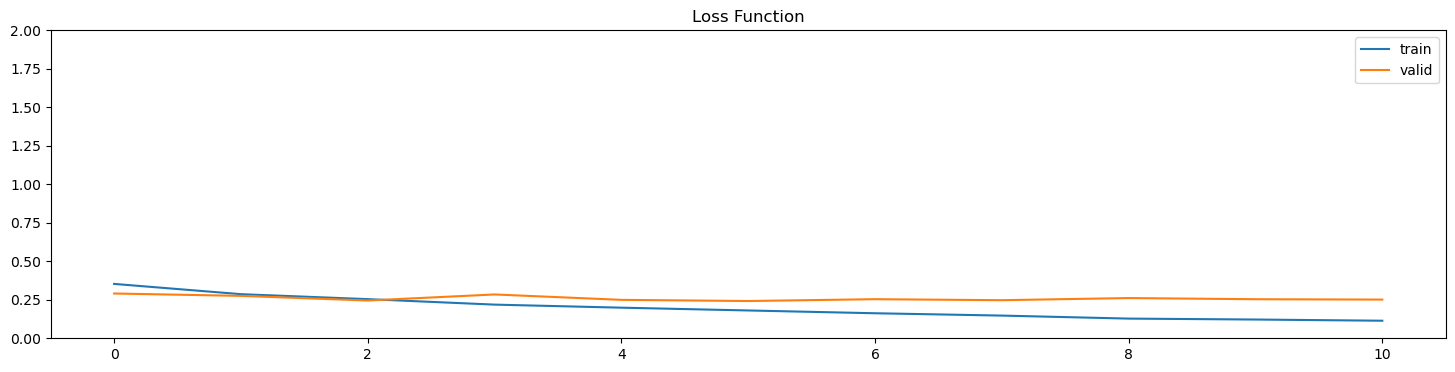

In [66]:
# Plot loss function value through epochs
plt.figure(figsize=(18, 4))
plt.plot(history.history['loss'], label = 'train')
plt.plot(history.history['val_loss'], label = 'valid')
plt.legend()
plt.ylim(0, 2)
plt.title('Loss Function')
plt.show()

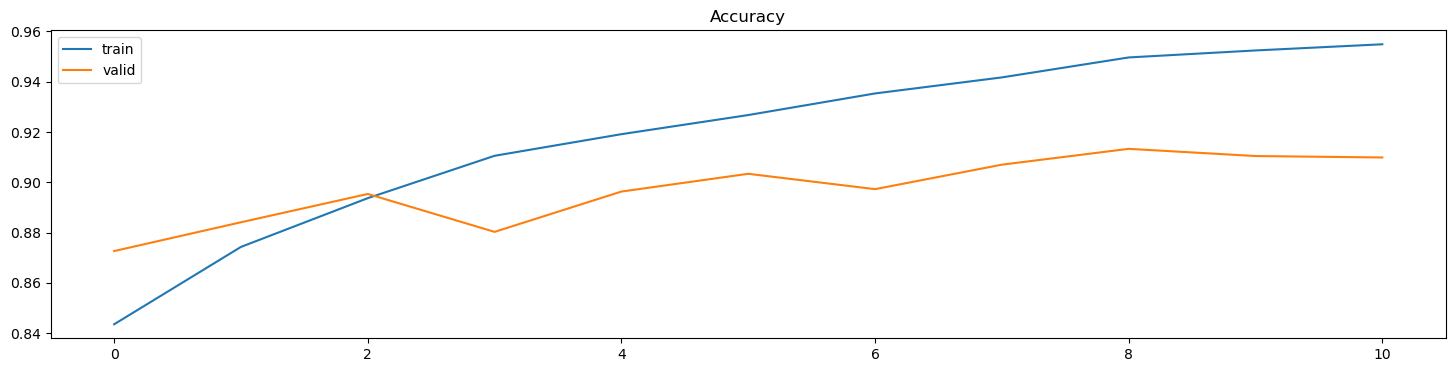

In [67]:
# Plot accuracy through epochs
plt.figure(figsize=(18, 4))
plt.plot(history.history['accuracy'], label = 'train')
plt.plot(history.history['val_accuracy'], label = 'valid')
plt.legend()
plt.title('Accuracy')
plt.show()

In [57]:
# test
test_loss, test_acc = our_model.evaluate(test_images, y_test, verbose=2)
print(f"EfficientNetB5 Test Accuracy: {test_acc}")


164/164 - 3427s - loss: 0.2512 - accuracy: 0.9099 - 3427s/epoch - 21s/step
EfficientNetB5 Test Accuracy: 0.9098548293113708
